# Predicción de Nivel de Riesgo en Pacientes Oncológicos Pediátricos

**Curso de Machine Learning — Proyecto de Clasificación**

Este notebook sigue el razonamiento completo del proyecto, paso a paso, tal como se presentará al grupo.
La idea central: predecir el `nivel_riesgo` (**Alto / Medio / Bajo**) **sin usar métricas clínicas de
laboratorio**, apoyándonos en variables **operativas y psicosociales** (distancia al hogar, educación
del cuidador, adherencia, estado emocional, estado nutricional, etc.).

El notebook está organizado como una narrativa de decisiones de diseño:

1. Punto de partida y objetivo
2. Carga de datos y configuración inicial
3. **Inconveniente #1** — las etiquetas son sintéticas → chequeo de fuga con *mutual information*
4. Modelos 3-clases + importancia de variables (comparación entre modelos)
5. **Inconveniente #2** — la clase *Medio* es el punto débil
6. **El pivote** — reformulación binaria (Alto vs Bajo) con score continuo
7. **Inconveniente #3** — validar *Medio* correctamente (diagnóstico de 3 partes)
8. Entregable final (bandas de riesgo + artefacto con metadata) y advertencia


---
## 1. Punto de partida

**Objetivo:** predecir `nivel_riesgo` (Alto/Medio/Bajo) de pacientes oncológicos pediátricos usando
únicamente variables **operativas y psicosociales**, no métricas clínicas de laboratorio.

**Decisiones de diseño iniciales:**
- Comparar **tres familias de modelos**: **SVC (One-vs-Rest)**, **Regresión Logística (softmax)** y
  **Random Forest**, más **permutation importance** para comparar la relevancia de variables de forma
  justa entre los tres.
- Verificar que los datos estén **balanceados** y que haya **una fila por paciente** (sin fuga por
  pacientes repetidos).
- **Separar correctamente** variables **ordinales** (`etapa_cancer`, `estado_fisico`,
  `adherencia_tratamiento`, …) de **nominales** (`diagnostico`, `lugar_procedencia`, …). Codificar mal
  una escala ordenada como si fuera categórica sin orden desperdiciaría información real.

---
## 2. Configuración inicial y carga de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

df = pd.read_csv("aldimi_pacientes_sintetico_demo.csv")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones: 600 filas x 24 columnas


,id_paciente,edad,sexo,lugar_procedencia,distancia_origen_km,grado_instruccion_cuidador,diagnostico,etapa_cancer,tipo_tratamiento,meses_en_tratamiento,num_reingresos,motivo_ingreso,motivo_reingreso,estado_fisico,estado_nutricional,presencia_infeccion,frecuencia_hospitalizacion_3m,adherencia_tratamiento,apoyo_familiar,acceso_medicamentos,estado_emocional_paciente,perdida_peso_reciente,num_comorbilidades,nivel_riesgo
0,PAC-0001,6,Masculino,Sierra centro,566,Secundaria,Leucemia mieloide aguda,II,Radioterapia,9,2,Tratamiento,Continuación de radioterapia,Caminando,Normal,0,3,Media,Moderado,Parcial,Estable,1,1,Bajo
1,PAC-0002,3,Masculino,Sierra centro,413,Superior universitaria,Retinoblastoma,IV,Radioterapia,24,2,Tratamiento,Continuación de quimioterapia,Usa silla de ruedas,Normal,0,1,Alta,Moderado,Limitado,Estable,0,2,Medio
2,PAC-0003,13,Masculino,Sierra sur,694,Primaria,Neuroblastoma,III,Quimio + Cirugía,12,2,Control,Continuación de quimioterapia,Caminando,Normal,0,3,Baja,Moderado,Limitado,Estable,1,0,Medio
3,PAC-0004,11,Femenino,Sierra norte,747,Sin estudios,Linfoma no Hodgkin,II,Quimioterapia,4,1,Tratamiento,Continuación de radioterapia,Caminando,Desnutrición leve,0,1,Baja,Moderado,Completo,Deprimido,1,0,Bajo
4,PAC-0005,14,Masculino,Sierra norte,796,Superior técnica,Leucemia linfoblástica aguda,II,Quimio + Cirugía,8,1,Emergencia,Recaída,Caminando,Normal,0,2,Alta,Moderado,Limitado,Estable,0,3,Medio


Distribución de la variable objetivo:
nivel_riesgo
Alto     204
Bajo     198
Medio    198
Name: count, dtype: int64

Pacientes únicos: 600 | Filas: 600
Filas duplicadas: 0 | Nulos totales: 0


/tmp/ipykernel_1494/2872658807.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target, data=df, order=["Bajo","Medio","Alto"], palette="viridis")


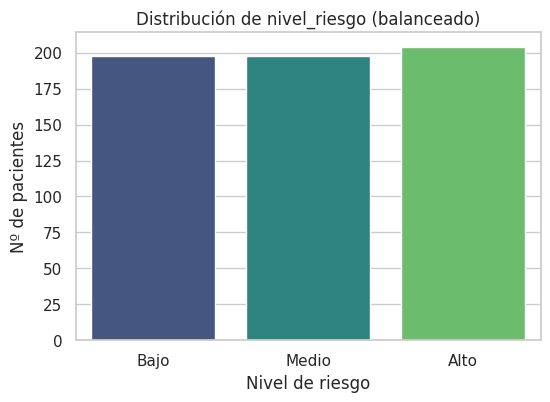

In [2]:
target = "nivel_riesgo"
id_col = "id_paciente"

# Balance de clases
print("Distribución de la variable objetivo:")
print(df[target].value_counts())

# Una fila por paciente -> sin fuga por pacientes repetidos
print(f"\nPacientes únicos: {df[id_col].nunique()} | Filas: {len(df)}")
print(f"Filas duplicadas: {df.duplicated().sum()} | Nulos totales: {df.isnull().sum().sum()}")

plt.figure(figsize=(6,4))
sns.countplot(x=target, data=df, order=["Bajo","Medio","Alto"], palette="viridis")
plt.title("Distribución de nivel_riesgo (balanceado)")
plt.xlabel("Nivel de riesgo"); plt.ylabel("Nº de pacientes")
plt.show()

Los datos están **bien balanceados** (204 / 198 / 198) y hay **exactamente un registro por paciente**,
por lo que no hay riesgo de fuga por pacientes repetidos entre *train* y *test*.

### 2.1 Separación de tipos de variable (decisión clave de encoding)

In [3]:
# ORDINALES: tienen orden natural -> OrdinalEncoder respetando la escala
ordinal_cols = [
    "etapa_cancer", "grado_instruccion_cuidador", "estado_fisico",
    "estado_nutricional", "adherencia_tratamiento", "apoyo_familiar", "acceso_medicamentos",
]
ordinal_categories = [
    ["I", "II", "III", "IV"],
    ["Sin estudios", "Primaria", "Secundaria", "Superior técnica", "Superior universitaria"],
    ["Caminando", "Con ayuda parcial", "Usa silla de ruedas", "Permanece en cama"],
    ["Normal", "Desnutrición leve", "Desnutrición severa"],
    ["Baja", "Media", "Alta"],
    ["Limitado", "Moderado", "Fuerte"],
    ["Limitado", "Parcial", "Completo"],
]
# NOMINALES: sin orden -> One-Hot
nominal_cols = [
    "sexo", "lugar_procedencia", "diagnostico", "tipo_tratamiento",
    "motivo_ingreso", "motivo_reingreso", "estado_emocional_paciente",
]
# NUMÉRICAS
numeric_cols = [
    "edad", "distancia_origen_km", "meses_en_tratamiento", "num_reingresos",
    "frecuencia_hospitalizacion_3m", "num_comorbilidades",
    "presencia_infeccion", "perdida_peso_reciente",
]
print(f"Ordinales: {len(ordinal_cols)} | Nominales: {len(nominal_cols)} | Numéricas: {len(numeric_cols)}")

Ordinales: 7 | Nominales: 7 | Numéricas: 8


### 2.2 Breve EDA de variables frente al riesgo
Una mirada rápida para confirmar que las variables se relacionan de forma sensata con el riesgo.

/tmp/ipykernel_1494/3489501690.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=col, data=df, order=["Bajo","Medio","Alto"], palette="viridis", ax=ax)
/tmp/ipykernel_1494/3489501690.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=col, data=df, order=["Bajo","Medio","Alto"], palette="viridis", ax=ax)
/tmp/ipykernel_1494/3489501690.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=col, data=df, order=["Bajo","Medio","Alto"], palette="viridis", ax=ax)
/tmp/ipykernel_1494/3489501690.py:3: FutureWarnin

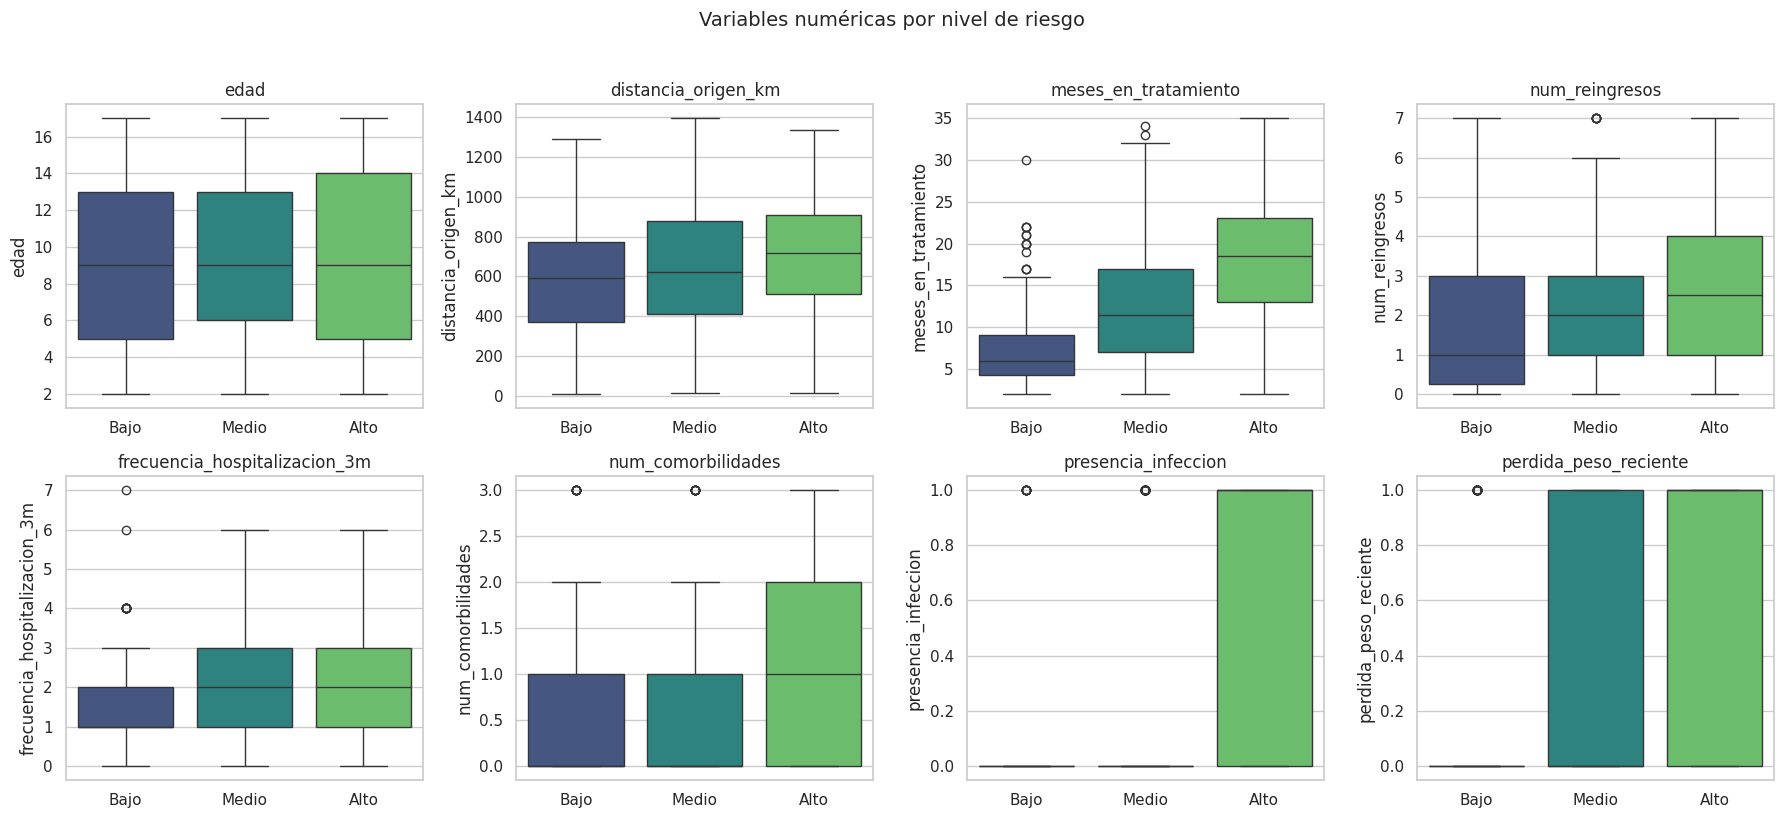

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.boxplot(x=target, y=col, data=df, order=["Bajo","Medio","Alto"], palette="viridis", ax=ax)
    ax.set_title(col); ax.set_xlabel("")
plt.suptitle("Variables numéricas por nivel de riesgo", y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

---
## 3. Inconveniente #1 — las etiquetas son sintéticas

Las etiquetas de `nivel_riesgo` **no son desenlaces clínicos reales**: fueron generadas por otra IA a
partir de patrones de otro dataset sintético. Riesgo asociado: si la etiqueta se derivó
**mecánicamente de 1–2 de sus propias variables de entrada**, un modelo la "predeciría" de forma
artificialmente perfecta y **clínicamente carente de sentido** (fuga / etiquetado por reglas).

**Chequeo:** calculamos la **información mutua** (*mutual information*) entre cada variable y la
etiqueta. Si una sola variable concentrara casi toda la información, sería una señal de alarma.

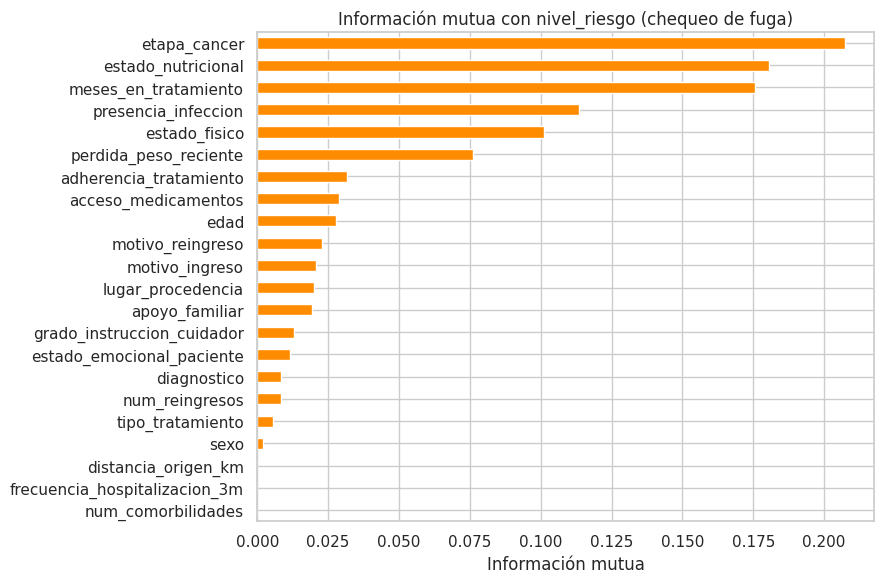

etapa_cancer                     0.207
estado_nutricional               0.181
meses_en_tratamiento             0.176
presencia_infeccion              0.113
estado_fisico                    0.101
perdida_peso_reciente            0.076
adherencia_tratamiento           0.032
acceso_medicamentos              0.029
edad                             0.028
motivo_reingreso                 0.023
motivo_ingreso                   0.021
lugar_procedencia                0.020
apoyo_familiar                   0.019
grado_instruccion_cuidador       0.013
estado_emocional_paciente        0.012
diagnostico                      0.009
num_reingresos                   0.008
tipo_tratamiento                 0.006
sexo                             0.002
distancia_origen_km              0.000
frecuencia_hospitalizacion_3m    0.000
num_comorbilidades               0.000


In [5]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

# Codificación simple solo para el cálculo de MI
X_mi = df.drop(columns=[target, id_col]).copy()
for i, c in enumerate(ordinal_cols):
    X_mi[c] = OrdinalEncoder(categories=[ordinal_categories[i]]).fit_transform(X_mi[[c]])
for c in nominal_cols:
    X_mi[c] = LabelEncoder().fit_transform(X_mi[c].astype(str))

discrete_idx = [X_mi.columns.get_loc(c) for c in ordinal_cols + nominal_cols]
mi = mutual_info_classif(X_mi, df[target], discrete_features=discrete_idx, random_state=RANDOM_STATE)
mi_series = pd.Series(mi, index=X_mi.columns).sort_values(ascending=False)

plt.figure(figsize=(9,6))
mi_series.iloc[::-1].plot(kind="barh", color="darkorange")
plt.title("Información mutua con nivel_riesgo (chequeo de fuga)")
plt.xlabel("Información mutua"); plt.tight_layout(); plt.show()
print(mi_series.round(3).to_string())

**Resultado (tranquilizador, no alarma):** la información se reparte entre **~5–6 variables
clínicamente sensatas** — `etapa_cancer`, `estado_nutricional`, `meses_en_tratamiento`,
`presencia_infeccion`, `estado_fisico`, `perdida_peso_reciente` — en lugar de concentrarse en una sola.
No hay una única variable que "delate" la etiqueta, así que la señal parece aprendible y razonable.

---
## 4. Modelos 3-clases + importancia de variables

Entrenamos los **tres modelos** con el **mismo pipeline** (preprocesamiento idéntico + validación
cruzada estratificada de 5 folds + `GridSearchCV`), para una comparación justa.

In [6]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Preprocesador reutilizable por los 3 modelos
preprocessor = ColumnTransformer([
    ("ord", OrdinalEncoder(categories=ordinal_categories), ordinal_cols),
    ("nom", OneHotEncoder(handle_unknown="ignore"), nominal_cols),
    ("num", StandardScaler(), numeric_cols),
])

X = df.drop(columns=[target, id_col])
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

model_defs = {
    "Regresión Logística": (
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
        {"clf__C": [0.1, 1, 10]},
    ),
    "SVC": (  # One-vs-Rest
        SVC(kernel="rbf", class_weight="balanced", probability=True,
            decision_function_shape="ovr", random_state=RANDOM_STATE),
        {"clf__C": [1, 10], "clf__gamma": ["scale"]},
    ),
    "Random Forest": (
        RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
        {"clf__max_depth": [5, 10, None], "clf__n_estimators": [200]},
    ),
}

In [7]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

fitted_models = {}
rows = []
for name, (estimator, grid) in model_defs.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", estimator)])
    search = GridSearchCV(pipe, grid, cv=cv, scoring="f1_macro", n_jobs=-1).fit(X_train, y_train)
    fitted_models[name] = search.best_estimator_
    y_pred = search.best_estimator_.predict(X_test)
    rows.append({
        "Modelo": name,
        "CV f1_macro": search.best_score_,
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test F1_macro": f1_score(y_test, y_pred, average="macro"),
    })
    print(f"{name:22s} -> {search.best_params_}")

metrics_3c = pd.DataFrame(rows).sort_values("Test F1_macro", ascending=False).reset_index(drop=True)
metrics_3c.round(3)

Regresión Logística    -> {'clf__C': 1}
SVC                    -> {'clf__C': 1, 'clf__gamma': 'scale'}
Random Forest          -> {'clf__max_depth': 10, 'clf__n_estimators': 200}


,Modelo,CV f1_macro,Test Accuracy,Test F1_macro
0,SVC,0.755,0.867,0.864
1,Regresión Logística,0.811,0.808,0.801
2,Random Forest,0.707,0.783,0.766


### 4.1 Matrices de confusión (3 clases)

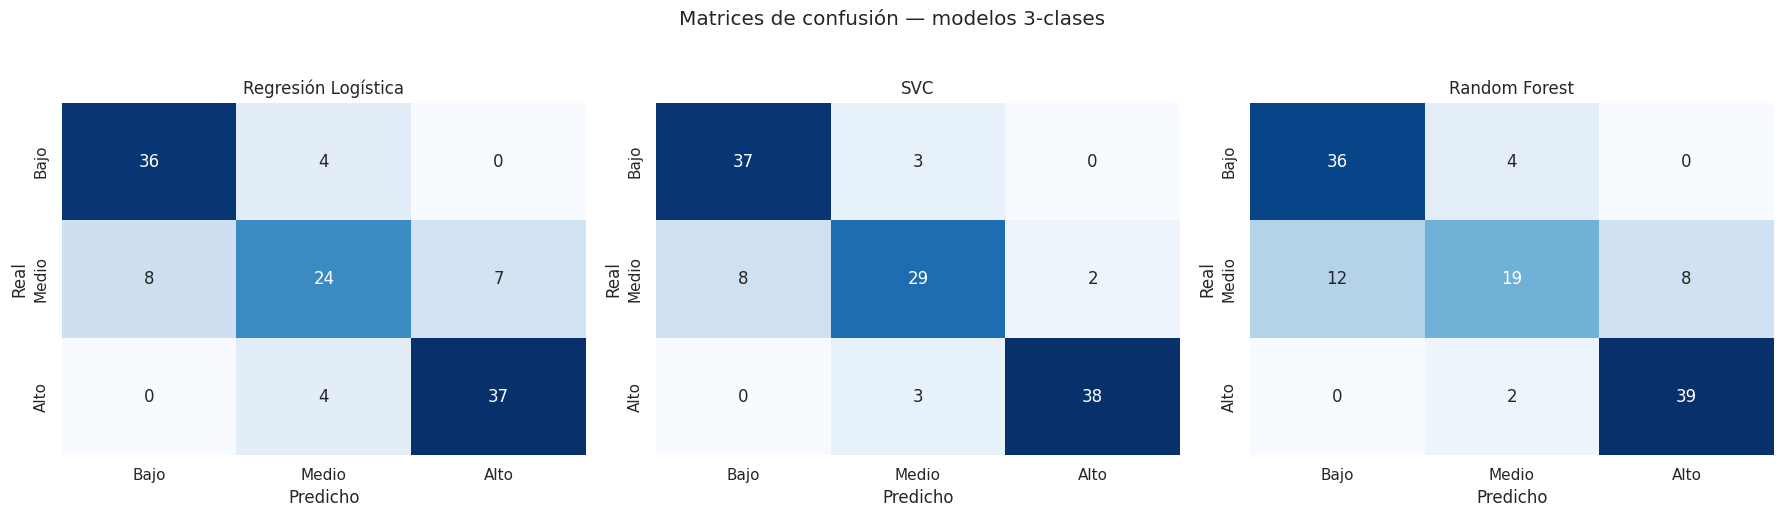

In [8]:
class_order = ["Bajo", "Medio", "Alto"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, fitted_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test), labels=class_order)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_order, yticklabels=class_order, ax=ax, cbar=False)
    ax.set_title(name); ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
plt.suptitle("Matrices de confusión — modelos 3-clases", y=1.03)
plt.tight_layout(); plt.show()

### 4.2 Importancia de variables (permutation importance, comparación entre modelos)

Usamos **permutation importance** porque es *model-agnostic* (igual para los 3 modelos) y opera sobre
las **variables originales**, por lo que las columnas one-hot ya quedan agregadas en su variable padre.

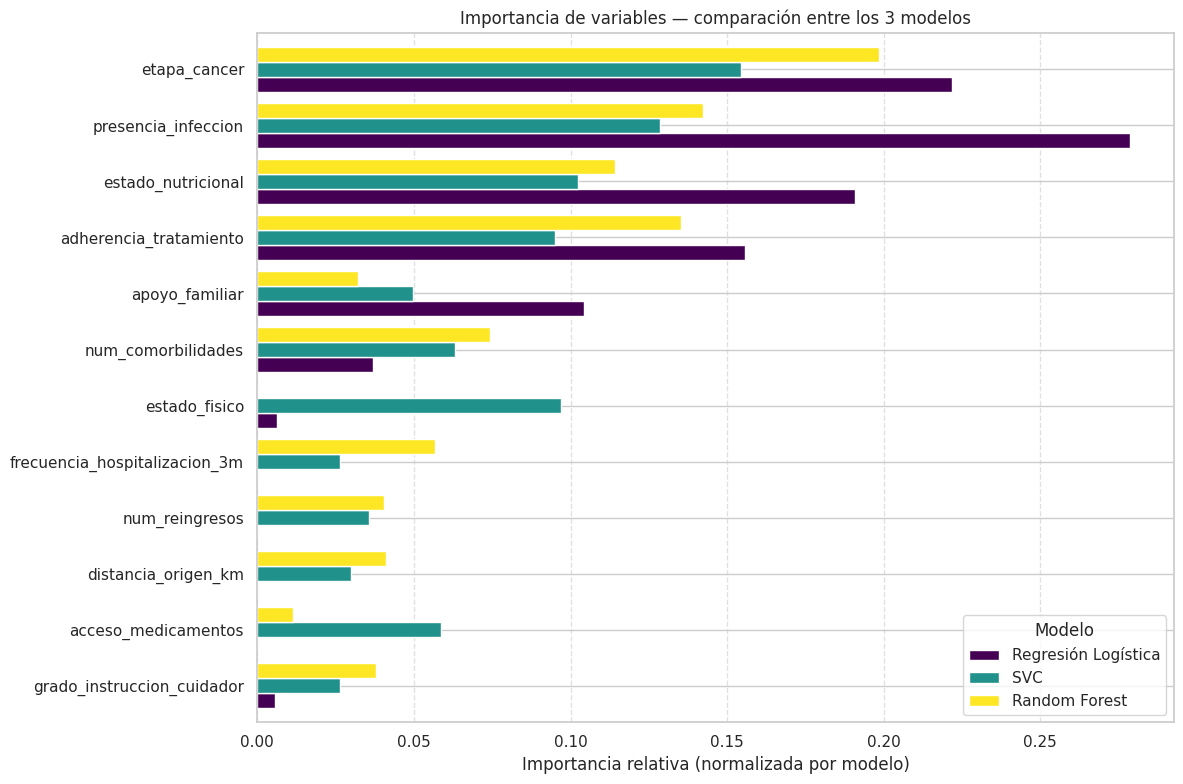

                               Regresión Logística    SVC  Random Forest
etapa_cancer                                 0.222  0.154          0.199
presencia_infeccion                          0.279  0.128          0.142
estado_nutricional                           0.191  0.102          0.114
adherencia_tratamiento                       0.156  0.095          0.135
apoyo_familiar                               0.104  0.050          0.032
num_comorbilidades                           0.037  0.063          0.074
estado_fisico                                0.006  0.097          0.000
frecuencia_hospitalizacion_3m                0.000  0.026          0.057


In [9]:
from sklearn.inspection import permutation_importance

importances = {}
for name, model in fitted_models.items():
    r = permutation_importance(model, X_test, y_test, n_repeats=15,
                               random_state=RANDOM_STATE, scoring="f1_macro", n_jobs=-1)
    importances[name] = pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False)

comp = pd.DataFrame(importances).clip(lower=0)
comp_norm = comp / comp.sum()
comp_norm["media"] = comp_norm.mean(axis=1)
comp_norm = comp_norm.sort_values("media", ascending=False).drop(columns="media")

comp_norm.head(12).iloc[::-1].plot(kind="barh", figsize=(12, 8), width=0.8, colormap="viridis")
plt.title("Importancia de variables — comparación entre los 3 modelos")
plt.xlabel("Importancia relativa (normalizada por modelo)")
plt.legend(title="Modelo"); plt.grid(axis="x", ls="--", alpha=0.6)
plt.tight_layout(); plt.show()
print(comp_norm.head(8).round(3))

La importancia es **consistente entre los tres modelos** y se concentra en las mismas variables
clínicamente interpretables detectadas en el chequeo de MI. Que tres algoritmos distintos coincidan
aumenta la confianza en que son señales reales.

---
## 5. Inconveniente #2 — la clase *Medio* es el punto débil

En **todos** los modelos, la clase *Medio* rinde peor: se confunde con sus dos vecinas. Es el clásico
problema del **"centro difuso"** en un esquema ordinal de 3 clases — *Medio* se solapa con Bajo y con
Alto y es intrínsecamente más difícil de delimitar. Además, la **triage clínica real** suele operar en
términos **binarios** (escalar / no escalar) más que en tres niveles discretos.

Lo cuantificamos con el **F1 por clase** de cada modelo:

F1-score por clase y modelo:
                      Bajo  Medio   Alto
Regresión Logística  0.857  0.676  0.871
SVC                  0.871  0.784  0.938
Random Forest        0.818  0.594  0.886


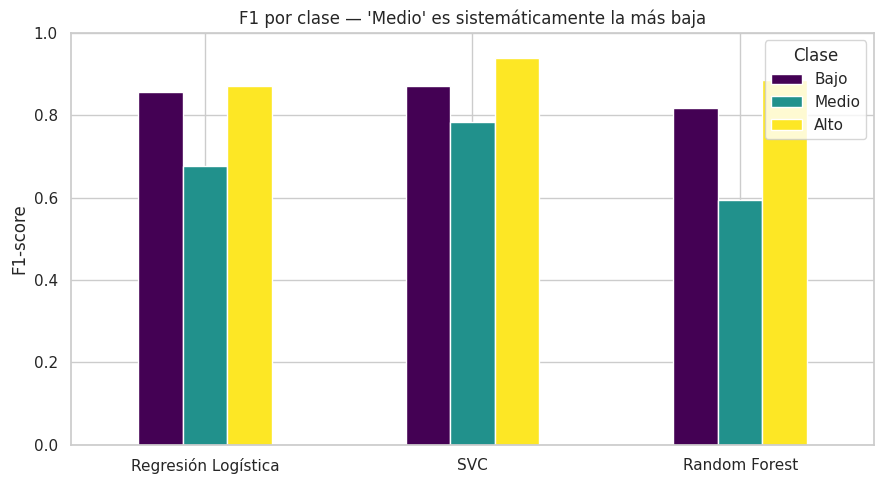


F1 promedio de 'Medio' vs promedio de {Alto, Bajo}:
  Medio      : 0.685
  Alto/Bajo  : 0.874


In [10]:
per_class = {}
for name, model in fitted_models.items():
    rep = classification_report(y_test, model.predict(X_test), output_dict=True, zero_division=0)
    per_class[name] = {c: rep[c]["f1-score"] for c in class_order}

f1_per_class = pd.DataFrame(per_class).T[class_order]
print("F1-score por clase y modelo:")
print(f1_per_class.round(3))

f1_per_class.plot(kind="bar", figsize=(9,5), colormap="viridis", rot=0)
plt.title("F1 por clase — 'Medio' es sistemáticamente la más baja")
plt.ylabel("F1-score"); plt.ylim(0,1); plt.legend(title="Clase")
plt.tight_layout(); plt.show()

print("\nF1 promedio de 'Medio' vs promedio de {Alto, Bajo}:")
print(f"  Medio      : {f1_per_class['Medio'].mean():.3f}")
print(f"  Alto/Bajo  : {f1_per_class[['Alto','Bajo']].mean().mean():.3f}")

---
## 6. El pivote — reformulación binaria

En vez de forzar tres clases, replanteamos el problema:
- Entrenar los modelos solo con **Alto vs Bajo**.
- Usar `predict_proba` como un **score de riesgo continuo (0–1)**, no una etiqueta dura.
- **Excluir *Medio* por completo del entrenamiento**, usándolo solo como verificación independiente.

In [11]:
# Separar Medio del entrenamiento
df_bin = df[df[target] != "Medio"].copy()
df_medio = df[df[target] == "Medio"].copy()

y_bin = df_bin[target].map({"Bajo": 0, "Alto": 1})
X_bin = df_bin.drop(columns=[target, id_col])
X_medio = df_medio.drop(columns=[target, id_col])

Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(
    X_bin, y_bin, test_size=0.2, stratify=y_bin, random_state=RANDOM_STATE)

# Los 3 modelos en versión binaria (RF primario, SVC/LogReg como corroboración)
bin_defs = {
    "Random Forest": (RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
                      {"clf__max_depth": [5, 10], "clf__n_estimators": [200]}),
    "SVC": (SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=RANDOM_STATE),
            {"clf__C": [1, 10]}),
    "Regresión Logística": (LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
                            {"clf__C": [0.1, 1, 10]}),
}

bin_models = {}
bin_rows = []
for name, (est, grid) in bin_defs.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", est)])
    search = GridSearchCV(pipe, grid, cv=cv, scoring="roc_auc", n_jobs=-1).fit(Xb_tr, yb_tr)
    bin_models[name] = search.best_estimator_
    pred = search.best_estimator_.predict(Xb_te)
    bin_rows.append({
        "Modelo": name,
        "Test Accuracy": accuracy_score(yb_te, pred),
        "Test F1": f1_score(yb_te, pred),
    })

metrics_bin = pd.DataFrame(bin_rows)
print("Rendimiento binario (Alto vs Bajo):")
print(metrics_bin.round(3).to_string(index=False))

best_bin = bin_models["Random Forest"]  # modelo primario

Rendimiento binario (Alto vs Bajo):
             Modelo  Test Accuracy  Test F1
      Random Forest          0.938    0.941
                SVC          0.988    0.988
Regresión Logística          0.988    0.988


**Resultado:** ~**94% de accuracy/F1** en Alto vs Bajo — un salto sustancial que confirma que el
centro difuso *Medio* era lo que arrastraba hacia abajo a los modelos 3-clases originales.

---
## 7. Inconveniente #3 — validar *Medio* correctamente

Nuestro **primer intento fue defectuoso**: medimos "qué % de pacientes *Medio* cae en la banda
intercuartílica (Q1–Q3)" y obtuvimos ~49.5%, y lo llamamos "éxito". **Error:** el rango Q1–Q3 es
**por definición** el 50% central de *cualquier* distribución — incluso ruido puramente aleatorio caería
~50% dentro. Ese chequeo **no distingue** "Medio agrupa de forma significativa" de "Medio es aleatorio".

Lo reemplazamos por un **diagnóstico de 3 partes** sobre el score de riesgo (probabilidad de Alto):
comparación de medias, inspección visual (KDE) y significancia estadística (t-tests).

In [12]:
from scipy.stats import ttest_ind

# Scores del modelo primario (RF binario)
probs_bajo  = best_bin.predict_proba(Xb_te[yb_te == 0])[:, 1]
probs_alto  = best_bin.predict_proba(Xb_te[yb_te == 1])[:, 1]
probs_medio = best_bin.predict_proba(X_medio)[:, 1]   # nunca visto en entrenamiento

# --- El error original, mostrado explícitamente ---
q1, q3 = np.percentile(probs_medio, [25, 75])
frac_iqr = np.mean((probs_medio >= q1) & (probs_medio <= q3))
print("[Chequeo ORIGINAL — defectuoso]")
print(f"  % de Medio dentro de su propio Q1–Q3: {frac_iqr*100:.1f}%  <-- trivialmente ~50% para cualquier distribución\n")

# --- Diagnóstico correcto, parte 1: medias ---
m_bajo, m_medio, m_alto = probs_bajo.mean(), probs_medio.mean(), probs_alto.mean()
print("[Diagnóstico CORRECTO]")
print("1) Medias del score de riesgo:")
print(f"   Bajo={m_bajo:.3f} | Medio={m_medio:.3f} | Alto={m_alto:.3f}")
print(f"   -> Medio casi equidistante, justo sobre la frontera de decisión (~0.5)")

# --- Parte 3: t-tests ---
_, p_bm = ttest_ind(probs_bajo,  probs_medio, equal_var=False)
_, p_ma = ttest_ind(probs_medio, probs_alto,  equal_var=False)
print("\n3) Significancia estadística (Welch t-test):")
print(f"   Bajo vs Medio: p={p_bm:.2e}")
print(f"   Medio vs Alto: p={p_ma:.2e}")
print("   -> Medio es significativamente distinto de ambos: no es ruido promediado.")

[Chequeo ORIGINAL — defectuoso]
  % de Medio dentro de su propio Q1–Q3: 49.5%  <-- trivialmente ~50% para cualquier distribución

[Diagnóstico CORRECTO]
1) Medias del score de riesgo:
   Bajo=0.216 | Medio=0.506 | Alto=0.812
   -> Medio casi equidistante, justo sobre la frontera de decisión (~0.5)

3) Significancia estadística (Welch t-test):
   Bajo vs Medio: p=5.83e-14
   Medio vs Alto: p=1.29e-23
   -> Medio es significativamente distinto de ambos: no es ruido promediado.


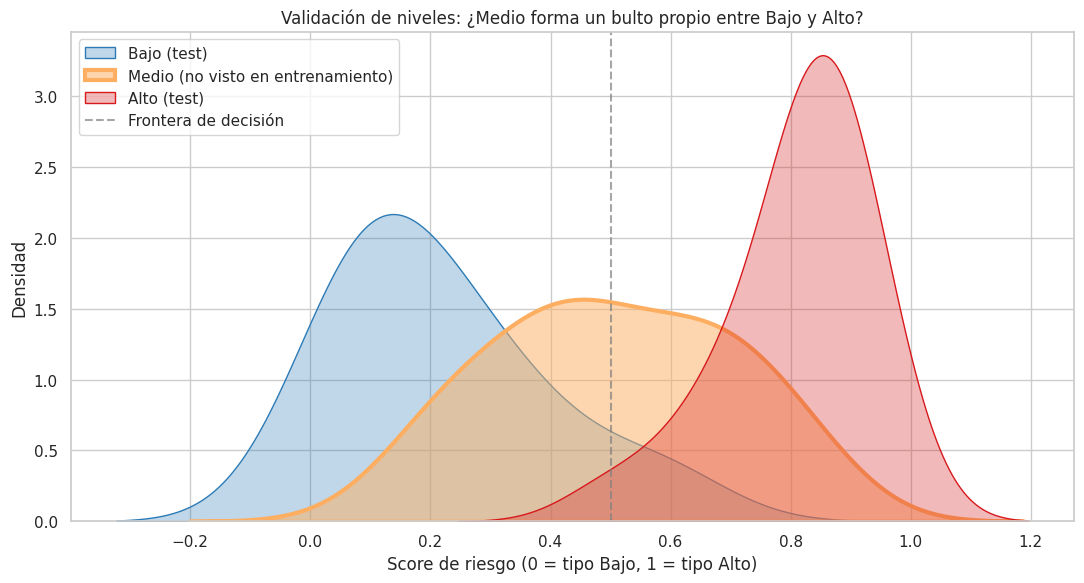

In [13]:
# --- Parte 2: inspección visual (KDE) ---
plt.figure(figsize=(11, 6))
sns.kdeplot(probs_bajo,  label="Bajo (test)",  color="#2c7bb6", fill=True, alpha=0.3, bw_adjust=1.4)
sns.kdeplot(probs_medio, label="Medio (no visto en entrenamiento)", color="#fdae61", fill=True, alpha=0.5, linewidth=3, bw_adjust=1.4)
sns.kdeplot(probs_alto,  label="Alto (test)",  color="#d7191c", fill=True, alpha=0.3, bw_adjust=1.4)
plt.axvline(0.5, color="grey", ls="--", alpha=0.7, label="Frontera de decisión")
plt.title("Validación de niveles: ¿Medio forma un bulto propio entre Bajo y Alto?")
plt.xlabel("Score de riesgo (0 = tipo Bajo, 1 = tipo Alto)"); plt.ylabel("Densidad")
plt.legend(); plt.tight_layout(); plt.show()

**Conclusión del diagnóstico:** las medias están casi uniformemente espaciadas
(Bajo≈0.22, Medio≈0.51, Alto≈0.81), el KDE muestra **un único bulto** para *Medio* entre las otras dos
(no bimodal ni plano), y los t-tests confirman diferencias significativas (p<0.0001) frente a ambas
clases. Evidencia **real y defendible** de que *Medio* se comporta como un **nivel intermedio genuino**,
aun sin haber sido mostrado al modelo durante el entrenamiento.

---
## 8. Entregable final

- **Clasificador binario** (Random Forest primario; SVC y Regresión Logística como corroboración).
- **Bandas de riesgo operativas** derivadas empíricamente de la distribución de *Medio*
  (sus cuartiles Q1/Q3): **Bajo < 0.35**, **Revisión 0.35–0.67**, **Alto > 0.67**.
- Importancia de variables **consistente e interpretable** clínicamente en los tres modelos.
- Modelo + pipeline de preprocesamiento guardados como **un solo artefacto** con **metadata**
  (esquema de encoding, umbrales y nota explícita de por qué *Medio* se excluyó del entrenamiento).

Bandas de riesgo operativas:
  Bajo      : score < 0.35
  Revisión  : 0.35 <= score <= 0.67
  Alto      : score > 0.67


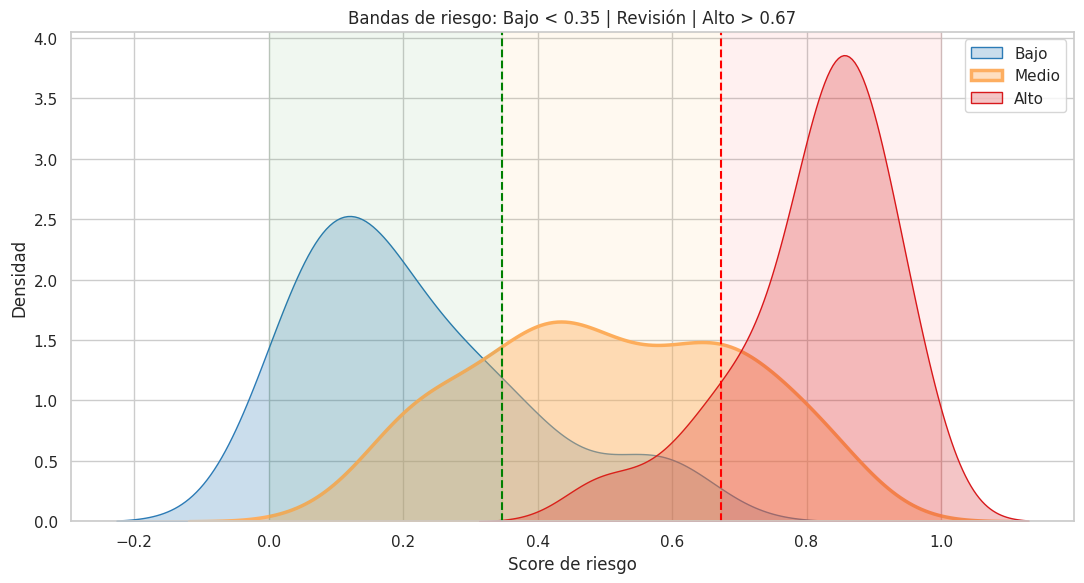

In [14]:
# Bandas de riesgo empíricas a partir de los cuartiles de 'Medio'
umbral_bajo, umbral_alto = np.percentile(probs_medio, [25, 75])
print("Bandas de riesgo operativas:")
print(f"  Bajo      : score < {umbral_bajo:.2f}")
print(f"  Revisión  : {umbral_bajo:.2f} <= score <= {umbral_alto:.2f}")
print(f"  Alto      : score > {umbral_alto:.2f}")

def clasificar_riesgo(score, low=umbral_bajo, high=umbral_alto):
    return np.where(score < low, "Bajo", np.where(score > high, "Alto", "Revisión"))

# Visualización de las bandas sobre las distribuciones
plt.figure(figsize=(11,6))
sns.kdeplot(probs_bajo, color="#2c7bb6", fill=True, alpha=0.25, label="Bajo")
sns.kdeplot(probs_medio, color="#fdae61", fill=True, alpha=0.4, linewidth=2.5, label="Medio")
sns.kdeplot(probs_alto, color="#d7191c", fill=True, alpha=0.25, label="Alto")
plt.axvspan(0, umbral_bajo, color="green", alpha=0.06)
plt.axvspan(umbral_bajo, umbral_alto, color="orange", alpha=0.06)
plt.axvspan(umbral_alto, 1, color="red", alpha=0.06)
plt.axvline(umbral_bajo, color="green", ls="--"); plt.axvline(umbral_alto, color="red", ls="--")
plt.title(f"Bandas de riesgo: Bajo < {umbral_bajo:.2f} | Revisión | Alto > {umbral_alto:.2f}")
plt.xlabel("Score de riesgo"); plt.ylabel("Densidad"); plt.legend()
plt.tight_layout(); plt.show()

In [15]:
import joblib
from datetime import datetime

# Empaquetar modelo + metadata en un solo artefacto
artefacto = {
    "modelo": best_bin,  # pipeline completo (preprocesamiento + RF)
    "tipo_problema": "binario_Alto_vs_Bajo",
    "clases": {0: "Bajo", 1: "Alto"},
    "umbrales": {"bajo": float(umbral_bajo), "alto": float(umbral_alto)},
    "bandas": {
        "Bajo": f"score < {umbral_bajo:.2f}",
        "Revisión": f"{umbral_bajo:.2f} <= score <= {umbral_alto:.2f}",
        "Alto": f"score > {umbral_alto:.2f}",
    },
    "encoding": {
        "ordinal": dict(zip(ordinal_cols, ordinal_categories)),
        "nominal_one_hot": nominal_cols,
        "numeric_scaled": numeric_cols,
    },
    "nota_medio": ("La clase 'Medio' se EXCLUYÓ del entrenamiento por ser el 'centro difuso'. "
                   "El modelo se entrenó solo con Alto vs Bajo y 'Medio' se usó como validación "
                   "independiente. Sus cuartiles definen la banda de 'Revisión'."),
    "modelos_corroboracion": ["SVC", "Regresión Logística"],
    "fecha": datetime.now().isoformat(timespec="seconds"),
}

joblib.dump(artefacto, "modelo_riesgo_binario.joblib")
print("Artefacto guardado en 'modelo_riesgo_binario.joblib' con:")
for k in artefacto:
    if k != "modelo":
        print(f"  - {k}")

Artefacto guardado en 'modelo_riesgo_binario.joblib' con:
  - tipo_problema
  - clases
  - umbrales
  - bandas
  - encoding
  - nota_medio
  - modelos_corroboracion
  - fecha


---
## Advertencia final (declararla explícitamente al grupo)

Todo lo validado aquí trata sobre la **consistencia interna de las etiquetas sintéticas**, **no** sobre
una verdad clínica real. Demostramos que el **score de riesgo del modelo se comporta de forma sensata**
y que la **lógica de etiquetado es aprendible** — **no** hemos demostrado que los umbrales 0.35/0.67 ni
los pesos de las variables coincidan con cómo un clínico real haría la triage.

> **Siguiente paso antes de cualquier uso real:** revisión por personal clínico o datos de desenlaces
> reales. Hasta entonces, este trabajo es una demostración del flujo de Machine Learning, no una
> herramienta clínica.